Lab 8 OvO & OvA

Jorge Angon, Swati K, George Rodriguez

Kaggle: https://www.kaggle.com/datasets/vetrirah/customer/code

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# load the dataset
df = pd.read_csv("Train.csv")

# look at the first few rows
print(df.head())

# show the size of the dataset
print("Dataset shape:", df.shape)

       ID  Gender Ever_Married  Age Graduated     Profession  Work_Experience  \
0  462809    Male           No   22        No     Healthcare              1.0   
1  462643  Female          Yes   38       Yes       Engineer              NaN   
2  466315  Female          Yes   67       Yes       Engineer              1.0   
3  461735    Male          Yes   67       Yes         Lawyer              0.0   
4  462669  Female          Yes   40       Yes  Entertainment              NaN   

  Spending_Score  Family_Size  Var_1 Segmentation  
0            Low          4.0  Cat_4            D  
1        Average          3.0  Cat_4            A  
2            Low          1.0  Cat_6            B  
3           High          2.0  Cat_6            B  
4           High          6.0  Cat_6            A  
Dataset shape: (8068, 11)


In [16]:
# remove the ID column because it is only an identifier
df = df.drop("ID", axis=1)

# fill missing number columns
df["Work_Experience"] = df["Work_Experience"].fillna(df["Work_Experience"].median())
df["Family_Size"] = df["Family_Size"].fillna(df["Family_Size"].median())

# fill missing text columns
df["Ever_Married"] = df["Ever_Married"].fillna(df["Ever_Married"].mode()[0])
df["Graduated"] = df["Graduated"].fillna(df["Graduated"].mode()[0])
df["Profession"] = df["Profession"].fillna(df["Profession"].mode()[0])
df["Var_1"] = df["Var_1"].fillna(df["Var_1"].mode()[0])

In [18]:
# separate features and target
X_raw = df.drop("Segmentation", axis=1)
y = df["Segmentation"]

# turn text columns into numbers
X = pd.get_dummies(X_raw, drop_first=True)

# show basic dataset information
print(f"Dataset: Customer Segmentation")
print(f"Number of samples: {len(y)}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")

Dataset: Customer Segmentation
Number of samples: 8068
Number of features: 22
Number of classes: 4
Classes: ['A' 'B' 'C' 'D']


In [19]:
# split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# train the standard SVM
start_time = time.time()
model_standard = SVC(kernel='rbf', gamma='scale', C=1.0)
model_standard.fit(X_train_scaled, y_train)
train_time_standard = time.time() - start_time

# make predictions
y_pred_standard = model_standard.predict(X_test_scaled)
accuracy_standard = accuracy_score(y_test, y_pred_standard)

# show results
print(f"Results:")
print(f"  Training time: {train_time_standard:.4f} seconds")
print(f"  Accuracy: {accuracy_standard * 100:.2f}%")

Results:
  Training time: 3.6450 seconds
  Accuracy: 52.54%


In [23]:
# train the OvA model
start_time = time.time()
model_ova = OneVsRestClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
model_ova.fit(X_train_scaled, y_train)
train_time_ova = time.time() - start_time

# make predictions
y_pred_ova = model_ova.predict(X_test_scaled)
accuracy_ova = accuracy_score(y_test, y_pred_ova)

# show results
print(f"Results:")
print(f"  Training time: {train_time_ova:.4f} seconds")
print(f"  Accuracy: {accuracy_ova * 100:.2f}%")
print(f"  Number of classifiers trained: {len(model_ova.estimators_)}")

print("\nClassification Report (OvA):")
print(classification_report(y_test, y_pred_ova))

print("Confusion Matrix (OvA):")
print(confusion_matrix(y_test, y_pred_ova))

Results:
  Training time: 11.0792 seconds
  Accuracy: 50.99%
  Number of classifiers trained: 4

Classification Report (OvA):
              precision    recall  f1-score   support

           A       0.41      0.35      0.37       394
           B       0.44      0.20      0.27       372
           C       0.51      0.65      0.57       394
           D       0.59      0.78      0.67       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.47      1614
weighted avg       0.49      0.51      0.48      1614

Confusion Matrix (OvA):
[[136  51  85 122]
 [ 89  74 152  57]
 [ 39  27 258  70]
 [ 69  16  14 355]]


In [24]:
# train the OvO model
start_time = time.time()
model_ovo = OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
model_ovo.fit(X_train_scaled, y_train)
train_time_ovo = time.time() - start_time

# make predictions
y_pred_ovo = model_ovo.predict(X_test_scaled)
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)

# show results
print(f"Results:")
print(f"  Training time: {train_time_ovo:.4f} seconds")
print(f"  Accuracy: {accuracy_ovo * 100:.2f}%")
print(f"  Number of classifiers trained: {len(model_ovo.estimators_)}")

print("\nClassification Report (OvO):")
print(classification_report(y_test, y_pred_ovo))

print("Confusion Matrix (OvO):")
print(confusion_matrix(y_test, y_pred_ovo))

Results:
  Training time: 8.5111 seconds
  Accuracy: 52.73%
  Number of classifiers trained: 6

Classification Report (OvO):
              precision    recall  f1-score   support

           A       0.42      0.46      0.44       394
           B       0.42      0.29      0.35       372
           C       0.56      0.57      0.57       394
           D       0.64      0.74      0.69       454

    accuracy                           0.53      1614
   macro avg       0.51      0.52      0.51      1614
weighted avg       0.52      0.53      0.52      1614

Confusion Matrix (OvO):
[[180  73  55  86]
 [109 109 112  42]
 [ 51  55 226  62]
 [ 89  21   8 336]]


In [30]:
# compare all strategies
print("=" * 70)
print("FINAL COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Strategy':<20} {'Accuracy':<12} {'Training Time':<15} {'# Classifiers'}")
print("-" * 70)
print(f"{'Standard SVM':<20} {accuracy_standard*100:>6.2f}%     {train_time_standard:>8.4f}s      N/A (built-in)")
print(f"{'One-vs-Rest (OvA)':<20} {accuracy_ova*100:>6.2f}%     {train_time_ova:>8.4f}s      {len(model_ova.estimators_)}")
print(f"{'One-vs-One (OvO)':<20} {accuracy_ovo*100:>6.2f}%     {train_time_ovo:>8.4f}s      {len(model_ovo.estimators_)}")

if accuracy_ovo > accuracy_ova:
    print(f"Better strategy for this dataset: One-vs-One (OvO)")
elif accuracy_ova > accuracy_ovo:
    print(f"Better strategy for this dataset: One-vs-Rest (OvA)")
else:
    print(f"Both strategies performed the same")

FINAL COMPARISON SUMMARY
Strategy             Accuracy     Training Time   # Classifiers
----------------------------------------------------------------------
Standard SVM          52.54%       3.6450s      N/A (built-in)
One-vs-Rest (OvA)     50.99%      11.0792s      4
One-vs-One (OvO)      52.73%       8.5111s      6
Better strategy for this dataset: One-vs-One (OvO)


In [33]:
# print the detailed report for the better strategy
if accuracy_ovo >= accuracy_ova:
    print(classification_report(y_test, y_pred_ovo))
else:
    print(classification_report(y_test, y_pred_ova))

              precision    recall  f1-score   support

           A       0.42      0.46      0.44       394
           B       0.42      0.29      0.35       372
           C       0.56      0.57      0.57       394
           D       0.64      0.74      0.69       454

    accuracy                           0.53      1614
   macro avg       0.51      0.52      0.51      1614
weighted avg       0.52      0.53      0.52      1614



In [35]:
# make one new customer row
new_customer = pd.DataFrame([{
    "Gender": "Male",
    "Ever_Married": "Yes",
    "Age": 35,
    "Graduated": "Yes",
    "Profession": "Engineer",
    "Work_Experience": 5,
    "Spending_Score": "Average",
    "Family_Size": 3,
    "Var_1": "Cat_4"
}])

# combine the new customer with the original input data
all_inputs = df.drop("Segmentation", axis=1)
combined_data = pd.concat([all_inputs, new_customer], ignore_index=True)

# turn text columns into numbers
combined_encoded = pd.get_dummies(combined_data, drop_first=True)

# grab only the last row because that is the new customer
new_customer_encoded = combined_encoded.tail(1)

# force the new row to have the same columns as the training data
new_customer_encoded = new_customer_encoded.reindex(columns=X.columns, fill_value=0)

# scale the new row
new_customer_scaled = scaler.transform(new_customer_encoded)

# predict the result with both models
ova_new_prediction = model_ova.predict(new_customer_scaled)[0]
ovo_new_prediction = model_ovo.predict(new_customer_scaled)[0]

print("OvA Prediction:", ova_new_prediction)
print("OvO Prediction:", ovo_new_prediction)

OvA Prediction: D
OvO Prediction: B


Generating visualization...


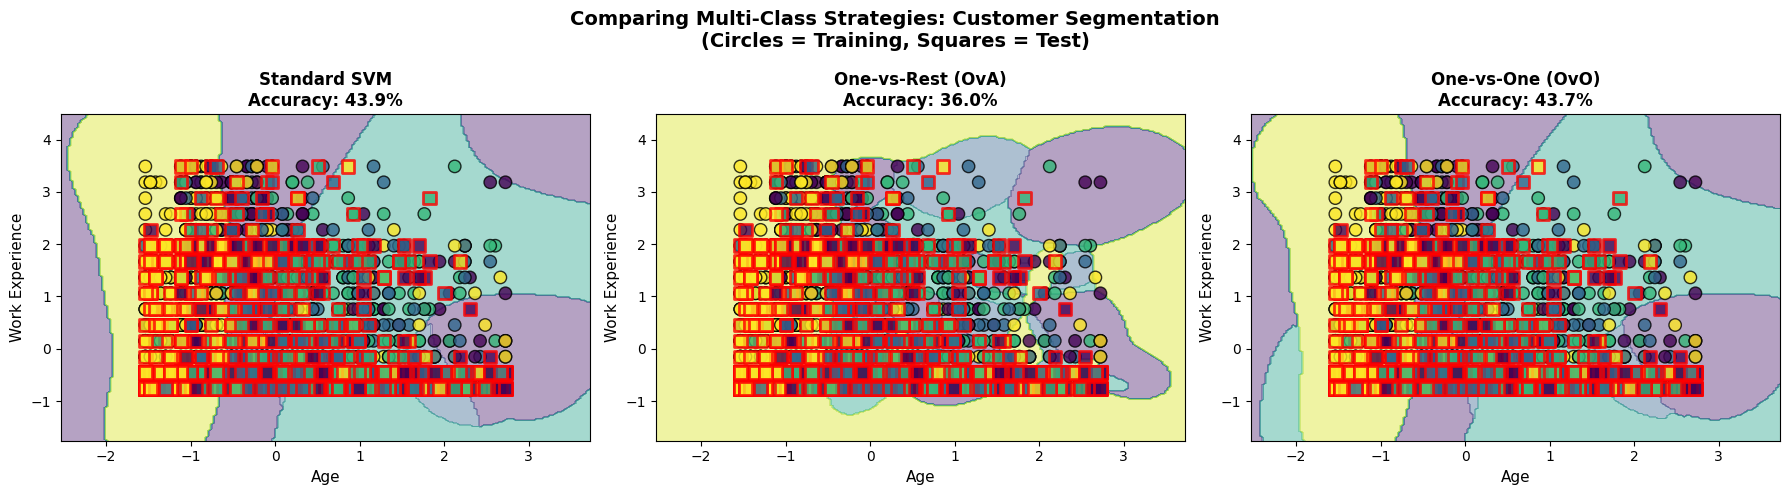

In [36]:
# tell the user a graph is being created
print("Generating visualization...")

# use only 2 numeric features for the graph
X_2d = df[["Age", "Work_Experience"]].copy()
y_2d = df["Segmentation"]

# turn class labels into numbers for coloring
class_names = sorted(y_2d.unique())
label_to_num = {label: i for i, label in enumerate(class_names)}
y_2d_num = y_2d.map(label_to_num)

# split the graph data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

# scale the graph data
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# create the 3 graph models
models_2d = {
    'Standard SVM': SVC(kernel='rbf', gamma='scale', C=1.0),
    'One-vs-Rest (OvA)': OneVsRestClassifier(SVC(kernel='rbf', gamma='scale', C=1.0)),
    'One-vs-One (OvO)': OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1
y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

for idx, (name, model) in enumerate(models_2d.items()):
    model.fit(X_train_2d_scaled, y_train_2d)

    y_pred_2d = model.predict(X_test_2d_scaled)
    acc_2d = accuracy_score(y_test_2d, y_pred_2d)

    Z_labels = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.array([label_to_num[label] for label in Z_labels])
    Z = Z.reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap='viridis')

    axes[idx].scatter(
        X_train_2d_scaled[:, 0],
        X_train_2d_scaled[:, 1],
        c=[label_to_num[label] for label in y_train_2d],
        edgecolors='k',
        cmap='viridis',
        s=80,
        alpha=0.8
    )

    axes[idx].scatter(
        X_test_2d_scaled[:, 0],
        X_test_2d_scaled[:, 1],
        c=[label_to_num[label] for label in y_test_2d],
        edgecolors='red',
        linewidths=2,
        cmap='viridis',
        s=80,
        alpha=0.8,
        marker='s'
    )

    axes[idx].set_xlabel('Age', fontsize=11)
    axes[idx].set_ylabel('Work Experience', fontsize=11)
    axes[idx].set_title(f'{name}\nAccuracy: {acc_2d*100:.1f}%', fontsize=12, fontweight='bold')

plt.suptitle(
    'Comparing Multi-Class Strategies: Customer Segmentation\n(Circles = Training, Squares = Test)',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

This project compared two SVM multiclass strategies called One-vs-All (OvA) and One-vs-One (OvO) using a customer segmentation dataset. The goal was to predict which customer group a person belongs to based on information such as age, profession, spending score, work experience, and family size.

After testing both methods, the OvO model performed slightly better than the OvA model. The OvA model reached 50.99% accuracy, while the OvO model reached 52.73% accuracy. OvA built 4 classifiers because there were 4 customer groups, while OvO built 6 classifiers because it compared each pair of groups. Even though OvO used more classifiers, it still gave the better result on this dataset.

This means the OvO method did a slightly better job sorting customers into groups. The model is not perfect, but it still shows how machine learning can help a business organize customers for targeting and planning. The new customer section also makes the project more practical because it shows how a brand new customer can be classified, and it also shows that different multiclass strategies can give different results.